# **Pavan S - 24BAD085**

---

# **Scenario 2: Item-Based Collaborative Filtering**

## Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error


## Loading the Dataset

In [11]:
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)


## Create Item-User Matrix

In [13]:
item_user = ratings.pivot_table(
    index='movieId',      # use title (or movieId if needed)
    columns='userId',
    values='rating'
)


(9724, 610)

## Handle Missing Values

In [14]:
item_user = item_user.fillna(0)

item_user.shape

(9724, 610)

## Cosine Similarity

In [19]:
item_similarity = cosine_similarity(item_user)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user.index,
    columns=item_user.index
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Top Similar Items

In [20]:
def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]

get_similar_items(1)

,1
movieId,
3114,0.572601
480,0.565637
780,0.564262
260,0.557388
356,0.547096


## Recommend items based on user history

In [21]:
def recommend_items(user_id, n=5):

    user_ratings = ratings[ratings['userId'] == user_id]

    scores = {}

    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        similar_items = get_similar_items(movie, 10)

        for sim_movie, sim_score in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                scores[sim_movie] = scores.get(sim_movie, 0) + sim_score * rating

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    top_items = [movie_id for movie_id, _ in sorted_scores[:n]]

    return movies[movies['movieId'].isin(top_items)]

recommend_items(1, 5)

,movieId,title,genres
337,380,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
902,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
1550,2087,Peter Pan (1953),Animation|Children|Fantasy|Musical
2195,2918,Ferris Bueller's Day Off (1986),Comedy


## Evaluation

In [24]:
def evaluate_rmse(sample_size=500):

    sample = ratings.sample(sample_size, random_state=42)

    actual = []
    predicted = []

    for _, row in sample.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']

        user_data = ratings[ratings['userId'] == user]

        weighted_sum = 0
        similarity_sum = 0

        for _, r in user_data.iterrows():
            sim = item_similarity_df.loc[movie, r['movieId']]
            if sim > 0:
                weighted_sum += sim * r['rating']
                similarity_sum += sim

        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum

            actual.append(true_rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(rmse)

evaluate_rmse()

0.9250189172879644


In [25]:
def precision_at_k(user_id, k=5, threshold=4.0):

    recs = recommend_items(user_id, k)
    rec_movie_ids = recs['movieId'].values

    user_data = ratings[ratings['userId'] == user_id]

    relevant = user_data[user_data['rating'] >= threshold]['movieId'].values

    hit = sum([1 for movie in rec_movie_ids if movie in relevant])

    precision = hit / k

    print(f"\nPrecision@{k}:", precision)

precision_at_k(1)


Precision@5: 0.0


## Analysis

In [26]:
movie_counts = ratings['movieId'].value_counts()

print("\nMost Popular Movies:")
print(movie_counts.head())

print("\nLeast Popular Movies:")
print(movie_counts.tail())


Most Popular Movies:
movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64

Least Popular Movies:
movieId
188833    1
189381    1
3899      1
2848      1
147002    1
Name: count, dtype: int64


## Visualization

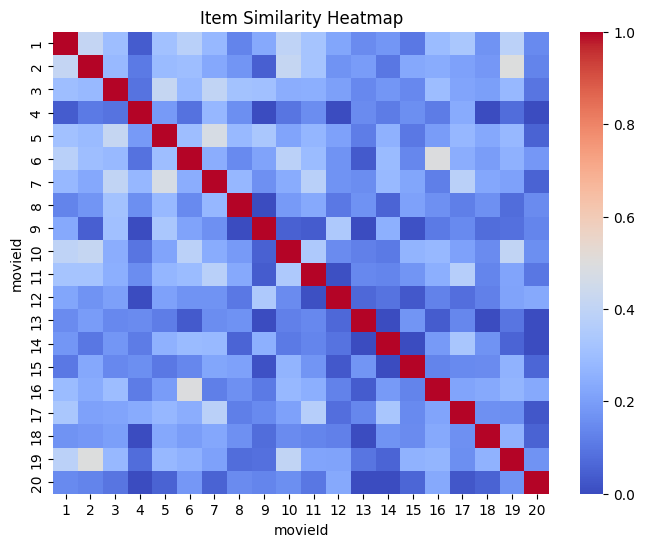

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.show()

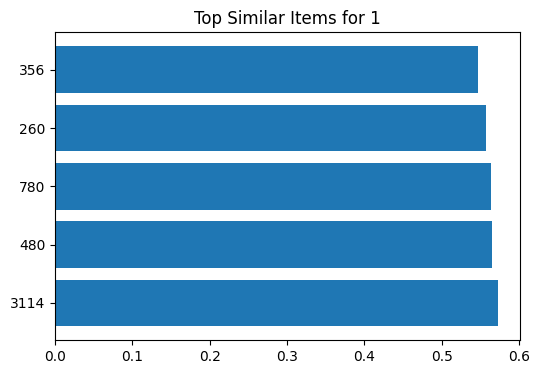

In [28]:
def plot_similar_items(movie_id):
    sims = get_similar_items(movie_id, 5)

    plt.figure(figsize=(6,4))
    plt.barh(sims.index.astype(str), sims.values)
    plt.title(f"Top Similar Items for {movie_id}")
    plt.show()

plot_similar_items(1)

In [29]:
def compare_user_item(user_id):
    item_recs = recommend_items(user_id, 5)

    print("\nItem-Based Recommendations:")
    print(item_recs[['title']])

compare_user_item(1)


Item-Based Recommendations:
                                  title
337                    True Lies (1994)
507   Terminator 2: Judgment Day (1991)
902                       Aliens (1986)
1550                   Peter Pan (1953)
2195    Ferris Bueller's Day Off (1986)
